# QRC Circuit Gallery

Displays the 5 quantum-reservoir circuit configurations implemented in the revamped
`qrc_gene/quantum_reservoir.py`, ported/adapted from the circuit-design sophistication
of [MagriLab/OptimalTraining_RFQRC](https://github.com/MagriLab/OptimalTraining_RFQRC)
(the more advanced sibling of the `Stability_QRC_GS` repo this project originally
referenced).

Every reservoir step applies up to three labelled blocks after an initial Hadamard layer:

| Block | Meaning |
|---|---|
| **H** | Hadamard layer -> superposition (required for interference/entanglement later) |
| **P** | *Recurrence* -- re-encodes the reservoir's own previous measurement (all $2^{n}$ basis probabilities) as rotation angles. This is genuine **quantum** memory, not a classical leaky average. Only configs 1-2 use it. |
| **X** | Encodes the current (scaled) plasma-state input. |
| **A** | A fixed, never-trained random-angle entangling unitary -- the reservoir's fixed internal dynamics. |

3 qubits are used below purely so the diagrams stay compact; the same code runs at any
`n_qubits` (see `01_QRC_GENE_Main.ipynb` / `02_QRC_Ensemble_Configuration.ipynb`).


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
from qrc_gene.quantum_reservoir import QuantumReservoirComputer, QRCConfig, CIRCUIT_CONFIG_INFO

N_QUBITS = 3   # kept small so the circuit diagrams stay readable
DIM = 3        # plasma-state dimension (matches the main notebook)


## The 5 circuit configurations, template view

Each diagram below is the **parameterised template** actually built once per reservoir
instance: `P` / `X` are live Qiskit `Parameter`s rebound every timestep via
`assign_parameters` (fast); `A` is baked in as fixed numbers immediately since it never
changes for a given reservoir instance. Barriers mark block boundaries.


Config 1: H -> P:linear (recurrent) -> X:full-ent -> A:full-ent-symmetric
  recurrent=True   N_units=2^3=8   gates=34   depth=26


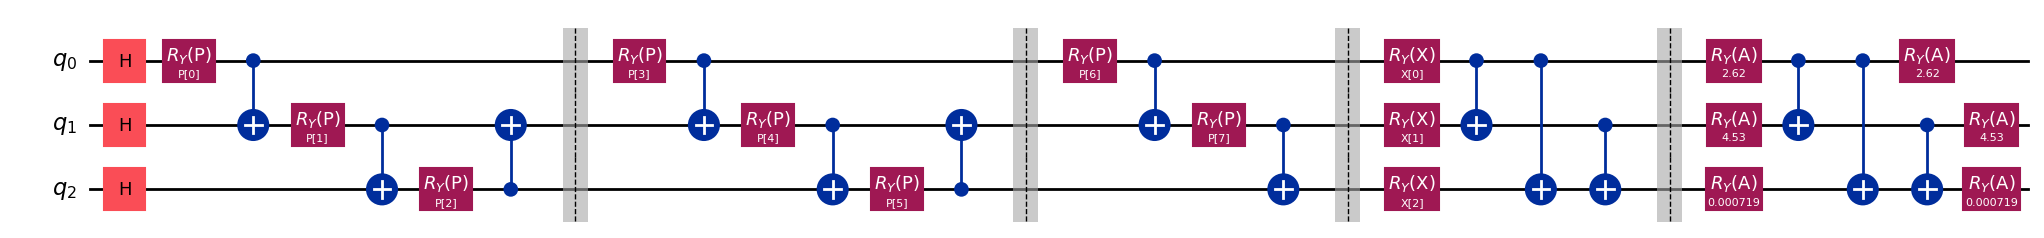

In [2]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config=1, seed=1)
qrc = QuantumReservoirComputer(cfg)
print(f"Config 1: {CIRCUIT_CONFIG_INFO[1]}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)

Config 2: H -> P:linear (recurrent) -> X:linear -> A:linear
  recurrent=True   N_units=2^3=8   gates=31   depth=29


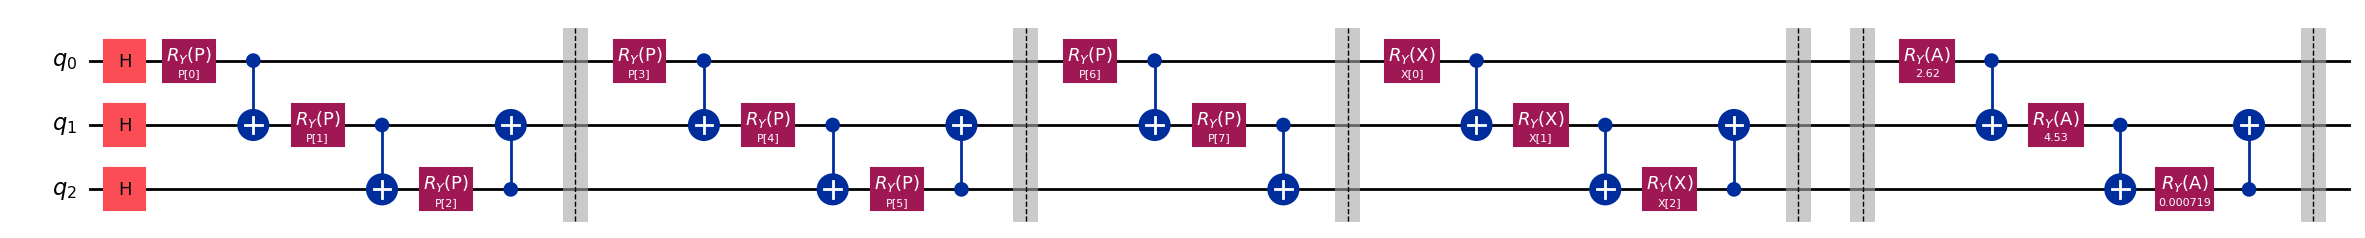

In [3]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config=2, seed=1)
qrc = QuantumReservoirComputer(cfg)
print(f"Config 2: {CIRCUIT_CONFIG_INFO[2]}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)

Config 3: H -> X:linear x2 (no recurrence) -> A:linear
  recurrent=False   N_units=2^3=8   gates=21   depth=19


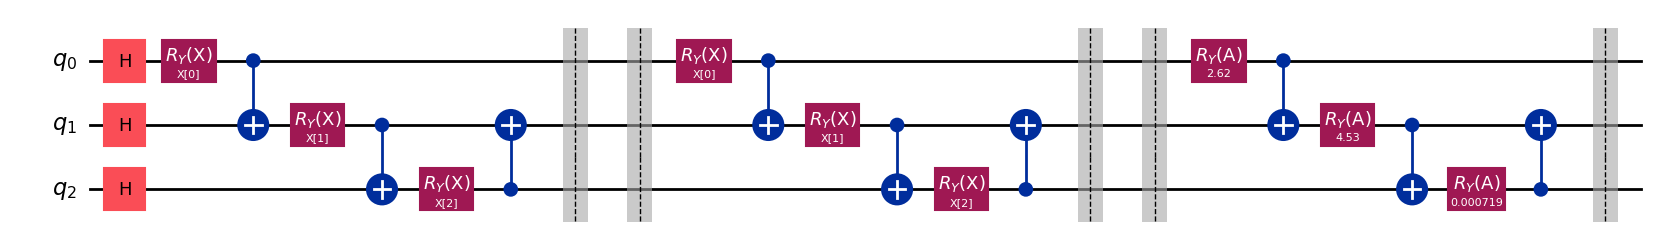

In [4]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config=3, seed=1)
qrc = QuantumReservoirComputer(cfg)
print(f"Config 3: {CIRCUIT_CONFIG_INFO[3]}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)

Config 4: H -> X:full-ent x2 (no recurrence) -> A:full-ent-symmetric
  recurrent=False   N_units=2^3=8   gates=24   depth=14


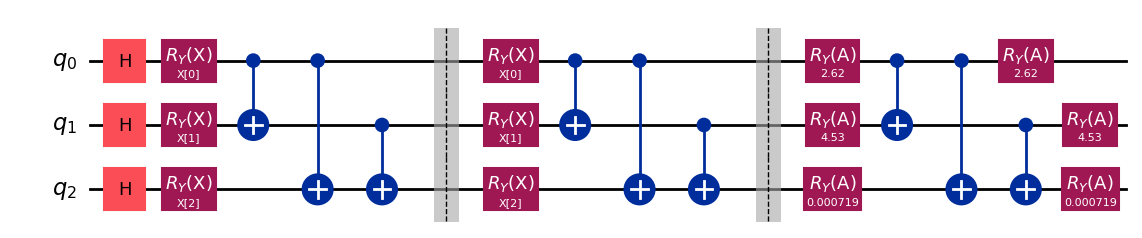

In [5]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config=4, seed=1)
qrc = QuantumReservoirComputer(cfg)
print(f"Config 4: {CIRCUIT_CONFIG_INFO[4]}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)

Config 5: H -> X:feature-product x2 (no recurrence) -> A:linear
  recurrent=False   N_units=2^3=8   gates=33   depth=27


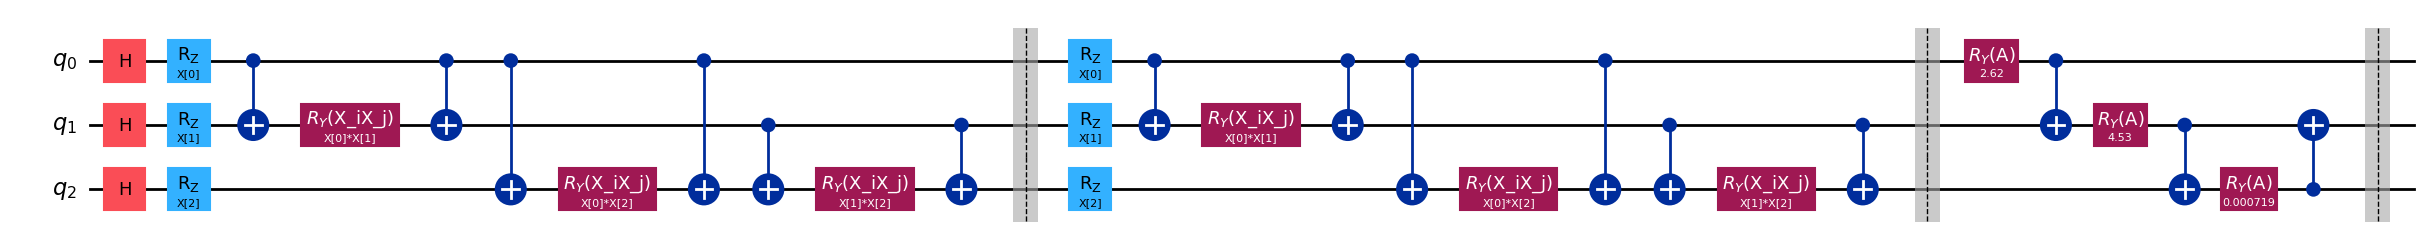

In [6]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config=5, seed=1)
qrc = QuantumReservoirComputer(cfg)
print(f"Config 5: {CIRCUIT_CONFIG_INFO[5]}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)

## What actually gets simulated: a fully-bound example (Config 1)

The template above has symbolic `P`/`X` parameters. At runtime every value is substituted
with real numbers (the reservoir's previous measured probabilities for `P`, the current
scaled plasma state for `X`) via `QuantumReservoirComputer.bind()` -- this is the exact
circuit object that gets passed to Qiskit's `Statevector.from_instruction` every single
timestep. Shown here with illustrative example values (`example_bound_circuit`).


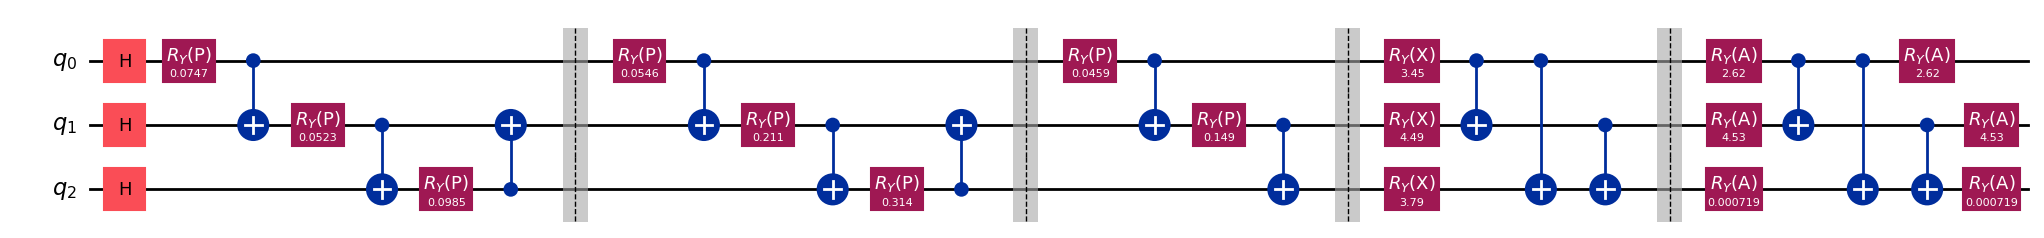

In [7]:
cfg1 = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config=1, seed=1)
qrc1 = QuantumReservoirComputer(cfg1)
bound_qc = qrc1.example_bound_circuit(seed=0)
bound_qc.draw(output="mpl", fold=-1)

## Cost comparison across configs and qubit counts

Configs 1-2 (recurrent) cost $O(2^{n\_qubits})$ *extra* gates for the `P` block (it
re-encodes the full $2^n$-dimensional probability vector every step), so their circuit
size grows much faster with qubit count than configs 3-5. This is the practical
trade-off between the richer quantum-recurrent memory and per-step simulation cost.


In [8]:
rows = []
for k in range(1, 6):
    for nq in [3, 4, 5, 6]:
        cfg = QRCConfig(n_qubits=nq, dim=DIM, circuit_config=k, seed=1)
        qrc = QuantumReservoirComputer(cfg)
        rows.append({"config": k, "recurrent": qrc.recurrent, "n_qubits": nq,
                      "N_units": qrc.N_units, "gates": qrc.template.size(),
                      "depth": qrc.template.depth()})
df = pd.DataFrame(rows)
df.pivot(index="config", columns="n_qubits", values="gates")

n_qubits,3,4,5,6
config,,,,
1,34,58,100,176
2,31,49,83,149
3,21,23,25,27
4,24,35,49,66
5,33,35,37,39


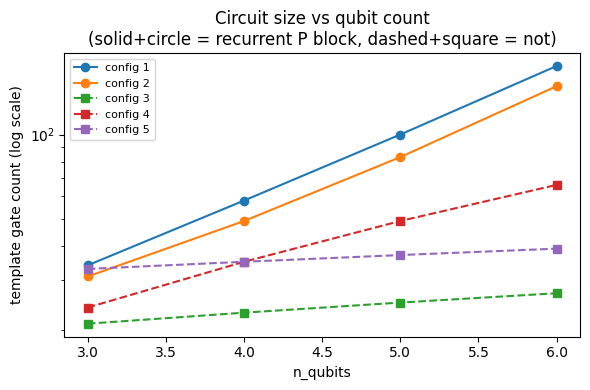

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for k, grp in df.groupby("config"):
    style = "-o" if grp["recurrent"].iloc[0] else "--s"
    ax.plot(grp["n_qubits"], grp["gates"], style, label=f"config {k}")
ax.set_yscale("log")
ax.set_xlabel("n_qubits"); ax.set_ylabel("template gate count (log scale)")
ax.set_title("Circuit size vs qubit count\n(solid+circle = recurrent P block, dashed+square = not)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Summary

| Config | Blocks | Recurrent (quantum memory) | Relative cost |
|---|---|---|---|
| 1 | P:linear, X:full-ent, A:full-ent-sym | Yes | High, grows fastest with qubits |
| 2 | P:linear, X:linear, A:linear | Yes | High, grows fastest with qubits |
| 3 | X:linear x2, A:linear | No | Low |
| 4 | X:full-ent x2, A:full-ent-sym | No | Medium |
| 5 | X:feature-product x2, A:linear | No | Medium (nonlinear encoding) |

Use configs 1-2 when the richest possible reservoir memory matters more than runtime
(small qubit counts); configs 3-5 scale far better for larger `n_qubits` and are good
defaults for the ensemble sweep in `02_QRC_Ensemble_Configuration.ipynb`.
